In [498]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from helpers import is_country

In [499]:
# We can see from the first research question that the biggest polluters are:
#1. China
#2. US
#3. Russia
#4. Japan
#5. Germany
#6. India
#7. UK
#8. Saudi Arabia
#9. Iran
#10. France

goliaths_iso3 = ["CHN", "USA", "RUS", "JPN", "DEU", "IND", "GBR", "SAU", "IRN", "FRA"]

In [500]:
# Load and filter data
df = pd.read_csv("data/owid-co2-data.csv")
df = df[df["iso_code"].apply(lambda x: is_country(x) if isinstance(x, str) else False)].copy()

START_YEAR = 1990
END_YEAR = int(df["year"].max())
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)].copy()

df_goliaths = df[df["iso_code"].isin(goliaths_iso3)].copy()

df_goliaths = df_goliaths[df_goliaths["co2"].notna()].copy()

df_goliaths.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
9899,China,1990,CHN,1.153583e+09,3.385122e+12,83.068,0.072,2483.534,21.384,0.869,...,19.043,7.329,0.024,0.044,0.072,0.003,4205.167,3050.701,-122.764,-4.943
9900,China,1991,CHN,1.170789e+09,3.508948e+12,99.573,0.085,2619.143,135.609,5.460,...,23.957,7.421,0.025,0.046,0.074,0.004,4315.059,3185.453,-161.227,-6.156
9901,China,1992,CHN,1.184574e+09,3.755038e+12,120.352,0.102,2731.290,112.147,4.282,...,23.790,7.516,0.026,0.047,0.076,0.004,4445.956,3302.529,-73.106,-2.677
9902,China,1993,CHN,1.197309e+09,4.126169e+12,140.333,0.117,2914.284,182.994,6.700,...,25.492,7.617,0.026,0.049,0.079,0.004,4591.354,3497.279,-104.192,-3.575
9903,China,1994,CHN,1.209003e+09,4.438753e+12,161.567,0.134,3093.891,179.606,6.163,...,25.425,7.725,0.027,0.050,0.081,0.004,4901.601,3692.746,-301.852,-9.756


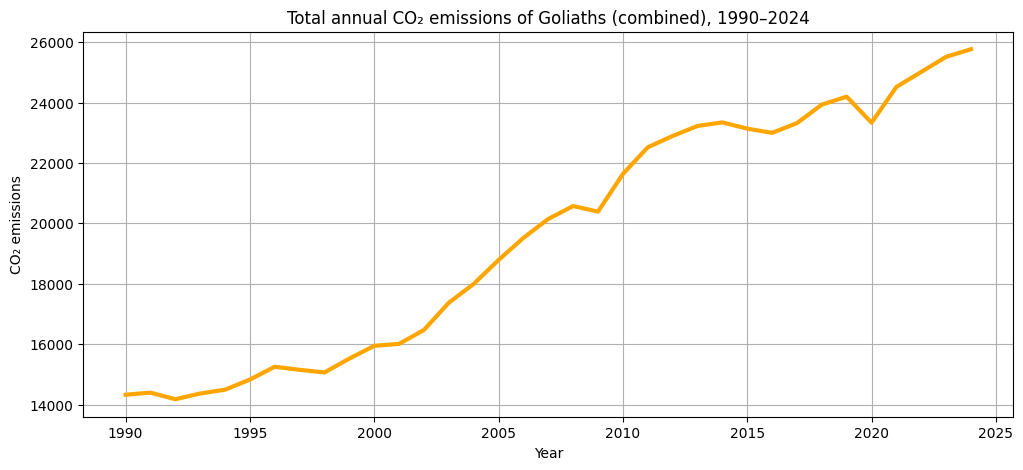

In [501]:
# Total annual CO2 emissions of all Goliaths combined
goliaths_total_yearly = (
    df_goliaths.groupby("year", as_index=False)["co2"]
    .sum()
    .rename(columns={"co2": "goliaths_total_co2"})
)

plt.figure(figsize=(12, 5))
plt.plot(
    goliaths_total_yearly["year"],
    goliaths_total_yearly["goliaths_total_co2"],
    linewidth=3,
    color='orange'
)
plt.title(f"Total annual CO₂ emissions of Goliaths (combined), {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.grid(True)
plt.show()

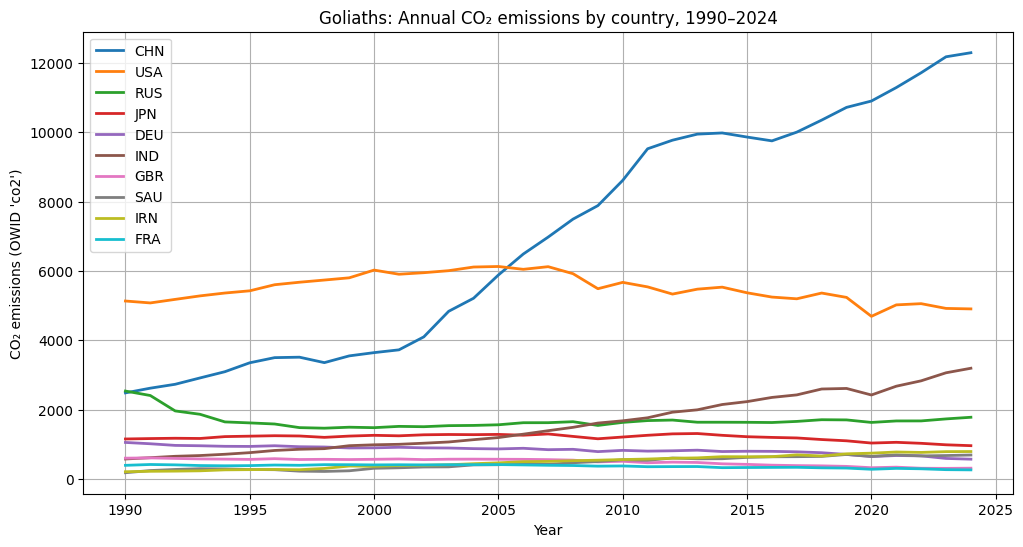

In [502]:
# Annual CO2 emissions per Goliath
goliaths_by_country_yearly = df_goliaths.pivot_table(
    index="year",
    columns="iso_code",
    values="co2",
    aggfunc="sum"
).reset_index()

plt.figure(figsize=(12, 6))

for code in goliaths_iso3:
    if code in goliaths_by_country_yearly.columns:
        plt.plot(
            goliaths_by_country_yearly["year"], 
            goliaths_by_country_yearly[code], 
            label=code,
            linewidth=2,
        )

plt.title(f"Goliaths: Annual CO₂ emissions by country, {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions (OWID 'co2')")
plt.grid(True)
plt.legend()
plt.show()


In [503]:
# We can see from the 3th research question that countries with the biggest mean temperature change are:
#1. Serbia
#2. Luxembourg
#3. Montenegro
#4. Estonia
#5. Belgium
#6. Belarus
#7. Latvia
#8. Russia
#9. Slovenia
#10. Lithuania
davids_iso3 = ["SRB", "LUX", "MNE", "EST", "BEL", "BLR", "LVA", "RUS", "SVN", "LTU"]

df_temp = pd.read_csv("data/AnnualMeanGlobalSurfaceTemperature.csv")
df_temp = df_temp[df_temp["ISO3"].apply(is_country)].copy()

year_cols = [c for c in df_temp.columns if c.isdigit() and START_YEAR <= int(c) <= END_YEAR]
df_davids = df_temp[df_temp["ISO3"].isin(davids_iso3)].copy()

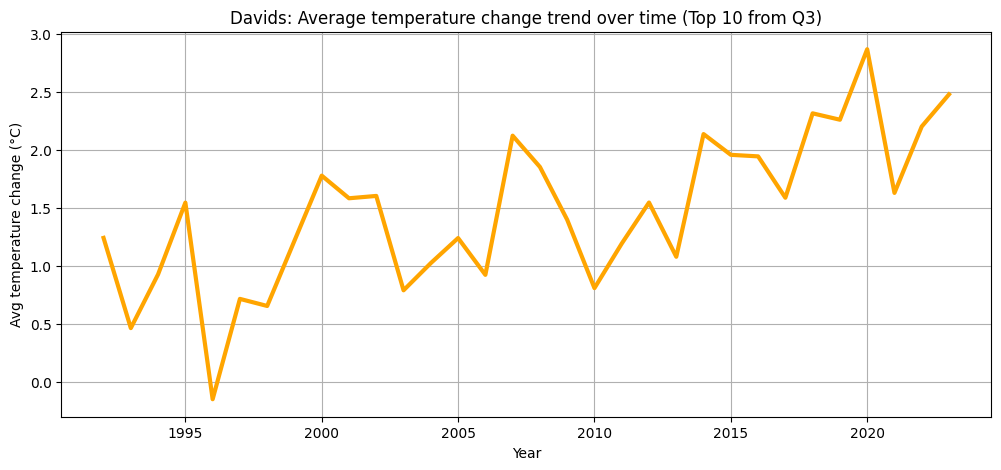

In [504]:
# Yearly averages ignore missing values
davids_yearly = df_davids[year_cols].mean(axis=0)

df_david_trend = pd.DataFrame({
    "year": [int(y) for y in year_cols],
    "davids_avg_temp_change": davids_yearly.values
}).sort_values("year")

plt.figure(figsize=(12, 5))
plt.plot(
    df_david_trend["year"], 
    df_david_trend["davids_avg_temp_change"], 
    linewidth=3,
    color="orange"
)
plt.title("Davids: Average temperature change trend over time (Top 10 from Q3)")
plt.xlabel("Year")
plt.ylabel("Avg temperature change (°C)")
plt.grid(True)
plt.show()

In [505]:
df_compare = pd.merge(
    goliaths_total_yearly[["year", "goliaths_total_co2"]],
    df_david_trend[["year", "davids_avg_temp_change"]],
    on="year",
    how="inner"
).sort_values("year")

df_compare.head(), df_compare.tail()

(   year  goliaths_total_co2  davids_avg_temp_change
 0  1990           14329.110                     NaN
 1  1991           14398.176                     NaN
 2  1992           14180.344                1.241167
 3  1993           14369.555                0.463667
 4  1994           14495.009                0.927333,
     year  goliaths_total_co2  davids_avg_temp_change
 29  2019           24192.451                  2.2595
 30  2020           23332.510                  2.8671
 31  2021           24515.871                  1.6288
 32  2022           25011.886                  2.2010
 33  2023           25512.190                  2.4779)

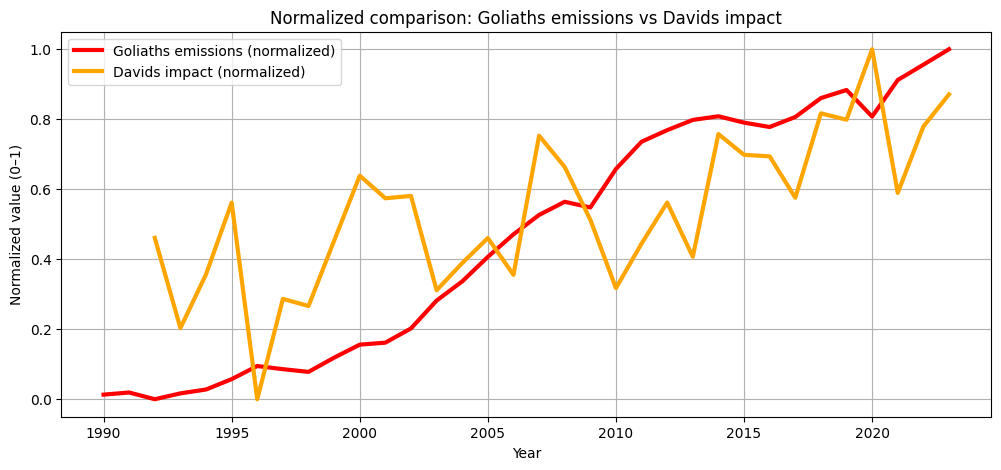

In [506]:
# Min–max normalization
df_norm = df_compare.copy()

df_norm["goliaths_norm"] = (
    (df_norm["goliaths_total_co2"] - df_norm["goliaths_total_co2"].min()) /
    (df_norm["goliaths_total_co2"].max() - df_norm["goliaths_total_co2"].min())
)

df_norm["davids_norm"] = (
    (df_norm["davids_avg_temp_change"] - df_norm["davids_avg_temp_change"].min()) /
    (df_norm["davids_avg_temp_change"].max() - df_norm["davids_avg_temp_change"].min())
)

plt.figure(figsize=(12, 5))
plt.plot(df_norm["year"], df_norm["goliaths_norm"], label="Goliaths emissions (normalized)", linewidth=3, color="red")
plt.plot(df_norm["year"], df_norm["davids_norm"], label="Davids impact (normalized)", linewidth=3, color="orange")
plt.title("Normalized comparison: Goliaths emissions vs Davids impact")
plt.xlabel("Year")
plt.ylabel("Normalized value (0–1)")
plt.grid(True)
plt.legend()
plt.show()

In [507]:
# Both normalized series (Goliaths’ emissions and Davids’ impact) trend upward over time, which suggests that rising emissions may be associated with increasing impacts on Davids.

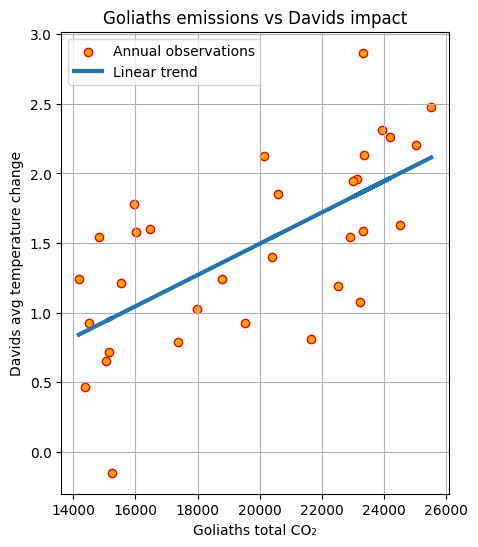

In [508]:
# Linear fit: y = m*x + b
tmp = df_compare[["goliaths_total_co2", "davids_avg_temp_change"]].replace([np.inf, -np.inf], np.nan).dropna()
x = tmp["goliaths_total_co2"].to_numpy()
y = tmp["davids_avg_temp_change"].to_numpy()
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

plt.figure(figsize=(5, 6))
plt.scatter(
    df_compare["goliaths_total_co2"], 
    df_compare["davids_avg_temp_change"], 
    color="orange", 
    edgecolors="red", 
    label="Annual observations"
)
plt.plot(x, y_fit, linewidth=3, label="Linear trend")
plt.title("Goliaths emissions vs Davids impact")
plt.xlabel("Goliaths total CO₂")
plt.ylabel("Davids avg temperature change")
plt.grid(True)
plt.legend()
plt.show()

In [509]:
# The upward trend line suggests a positive association, although the relationship is dispersed and not strictly linear.

In [510]:
tmp = df_compare[["goliaths_total_co2", "davids_avg_temp_change"]].replace([np.inf, -np.inf], np.nan).dropna()

pearson = tmp["goliaths_total_co2"].rank().corr(tmp["davids_avg_temp_change"].rank(), method="pearson")
print(f"Pearson: {pearson:.4f}")

Pearson: 0.7053


In [511]:
# The pearson correlation (~0.71) indicates a strong positive monotonic association between Goliaths’ emissions and Davids’ impact over time

In [512]:
# Top 10 Goliaths: combined share of global CO₂ over time
df_g_share = df_goliaths[df_goliaths["share_global_co2"].notna()].copy()

goliaths_share_yearly = (
    df_g_share.groupby("year", as_index=False)["share_global_co2"]
    .sum()
)

goliaths_share_yearly.head()

,year,share_global_co2
0,1990,63.035
1,1991,62.046
2,1992,62.968
3,1993,63.164
4,1994,63.092


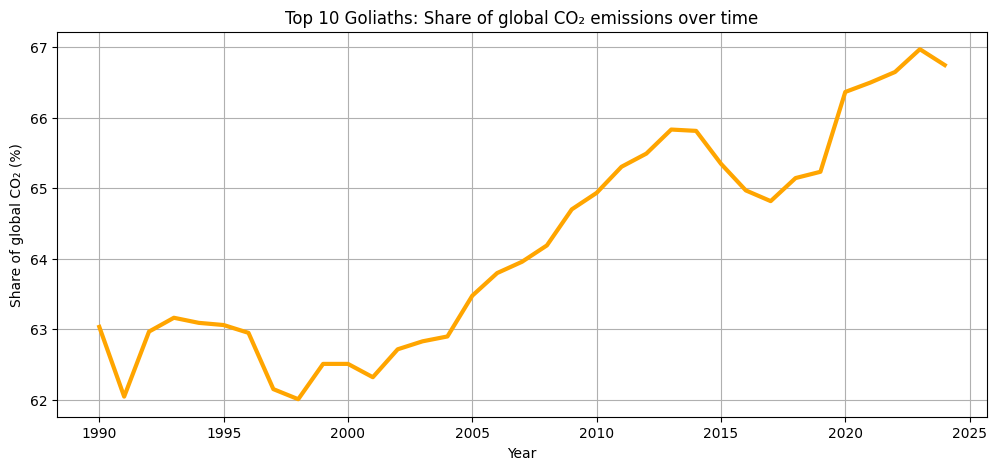

In [513]:
plt.figure(figsize=(12, 5))
plt.plot(
    goliaths_share_yearly["year"],
    goliaths_share_yearly["share_global_co2"],
    linewidth=3,
    color="orange"
)
plt.title("Top 10 Goliaths: Share of global CO₂ emissions over time")
plt.xlabel("Year")
plt.ylabel("Share of global CO₂ (%)")
plt.grid(True)
plt.show()

In [514]:
# The Top 10 Goliaths consistently account for the majority of global CO₂ emissions (roughly 62–67% across the period)

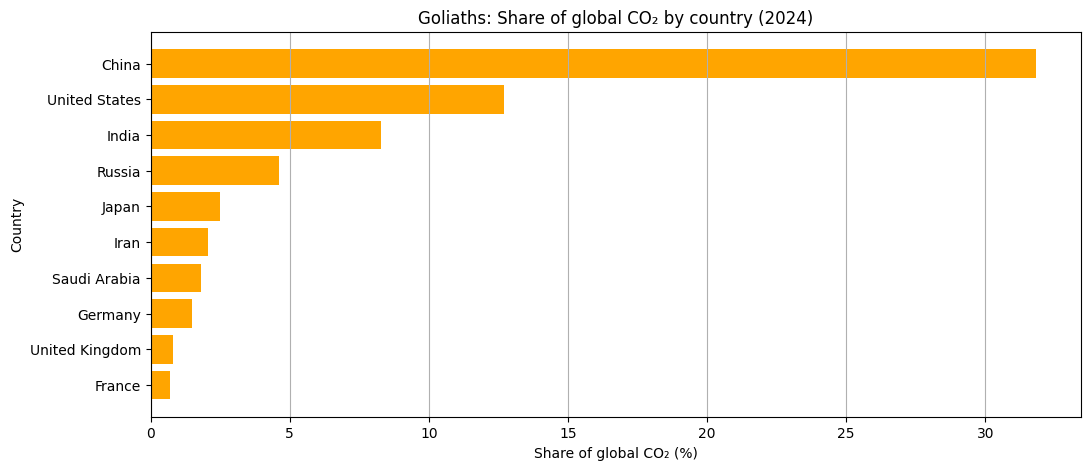

In [515]:
latest_year = int(goliaths_share_yearly["year"].max())

df_latest = df_g_share[df_g_share["year"] == latest_year][["country", "iso_code", "share_global_co2"]].copy()
df_latest = df_latest.sort_values("share_global_co2", ascending=False)

plt.figure(figsize=(12, 5))
plt.barh(df_latest["country"][::-1], df_latest["share_global_co2"][::-1], color="orange")
plt.title(f"Goliaths: Share of global CO₂ by country ({latest_year})")
plt.xlabel("Share of global CO₂ (%)")
plt.ylabel("Country")
plt.grid(True, axis="x")
plt.show()

In [516]:
# In the latest year, contributions within the Top 10 are highly uneven, China and the United States account for the largest shares